# Quantum Sensing Optimization with JAX-Compatible Machine Learning

This notebook demonstrates **gradient-based optimization of quantum sensing protocols** using gradient descent. We optimize rotation gate parameters to maximize photon detection sensitivity through dispersive qubit-cavity interactions.

## System Architecture

The simulation employs a **three-subsystem composite Hilbert space**:

1. **Input Cavity Mode**: Controls photon injection with temporal pulse shaping
2. **Resonator Cavity Mode**: Main sensing element coupled to the qubit detector  
3. **Two-Level Qubit**: Quantum sensor that responds to cavity photon presence

### **Quantum Sensing Workflow:**
```
|ψ₀⟩ → Ry(θ₁) → H(t) Evolution → Ry(θ₂) → Measurement → Detection Probability
```

#### **Optimization Strategy:**
1. **Initialize**: Prepare initial quantum state |0,1,0⟩ (single resonator photon)
2. **Rotate**: Apply first optimized rotation Ry(θ₁) to qubit
3. **Evolve**: Time evolution under dispersive cavity-qubit Hamiltonian  
4. **Rotate**: Apply second optimized rotation Ry(θ₂) for measurement preparation
5. **Measure**: Calculate qubit detection probabilities
6. **Optimize**: Use JAX automatic differentiation to find optimal θ₁, θ₂ 


## Required Libraries and Dependencies

Import the essential libraries for JAX-compatible quantum optimization and analysis:

- **JAX**: Automatic differentiation and high-performance numerical computing
- **QuTiP**: Quantum Toolbox in Python for quantum state manipulation and time evolution
- **QuTiP-JAX**: JAX backend integration for QuTiP enabling autodifferentiation
- **Optax**: JAX-based optimization algorithms (Adam, RMSprop, SGD, etc.)
- **NumPy**: Fundamental numerical operations and array handling
- **JAX.SciPy**: Scientific computing functions with JAX compatibility

### Visualization and Analysis:
- **Matplotlib**: Publication-quality plotting and visualization
- **Seaborn**: Statistical data visualization (loaded in visualization sections)

In [ ]:
import jax
import jax.numpy as jnp
import qutip as qt
import qutip_jax    
import numpy as np
import matplotlib.pyplot as plt
import optax  # JAX-based optimization library
import warnings
from jax.scipy.special import erfc

# Suppress Diffrax complex dtype warning
warnings.filterwarnings('ignore', message='Complex dtype support in Diffrax is a work in progress*')

# Verify JAX-QuTiP compatibility
print("JAX version:", jax.__version__)
print("QuTiP version:", qt.__version__)

## System Parameters

Key parameters for the three-system composite Hilbert space:
- **nlev**: Hilbert space dimension for each cavity (input + resonator)
- **chi**: Dispersive coupling strength between resonator and qubit
- **gm**: Resonator cavity decay rate (not used in time-independent evolution)
- **Evolution time**: Duration for Hamiltonian time evolution between rotations

In [2]:
gm  = .03 * 2 * np.pi                # photon-cavity coupling
sigma = .1*gm                        # inverse of the pulse width (sigma = 2*sqrt(log(2))/tpulse)
args = {'sigma': sigma}              # Arguments for the coefficient function
chi = .5*gm                          # Dispersive copling
nlev = 2                             # Number of cavity (and input field) levels
qlev = 2                             # Number of qubit levels
N_meas = 5                           # Number of measurments
tstep = 2.5/sigma                    # Time between measurments (normalized by sigma)
tmeas_var = 0.1/sigma                # Variance of single measurment
gamma_depol = 0.0001 * 2 * np.pi     # Gamma of depolarising noise
gamma_dephase = 0.0001 * 2 * np.pi   # Gamma of dephasing noise
gamma_relax = 0.0001 * 2 * np.pi     # Gamma of relaxation noise

trand_global = True                  # Toggle for random global time offset
trand_single = False                 # Toggle for random individual measure offset (Gaussian)
tstep_train = False                  # Toggle for training the time step between measurments (N_meas becomes variable)
Tdepol = True                        # Toggle for depolarisation Noise
Tdephase = True                     # Toggle for dephasing Noise
Trelax = True                       # Toggle for relaxation Noise

# Measurement times
tstart = -(N_meas-1)*tstep/2
tend = -tstart
tmeas = np.linspace(tstart, tend, N_meas)
#print(tmeas*sigma)


print(f"System parameters:")
print(f"  Cavity levels: {nlev}")
print(f"  Coupling photon-cavity (gamma): {gm}")
print(f"  Inverse of the pulse width (sigma): {sigma}")
print(f"  Dispersive copling (chi: {chi}")

System parameters:
  Cavity levels: 2
  Coupling photon-cavity (gamma): 0.18849555921538758
  Inverse of the pulse width (sigma): 0.01884955592153876
  Dispersive copling (chi: 0.09424777960769379


## Quantum Operators for Three-System Composite Space

Create operators for the composite Hilbert space: **input cavity ⊗ resonator cavity ⊗ qubit**

### Individual System Operators:
- **Input cavity**: Annihilation/creation operators
- **Resonator cavity**: Annihilation/creation operators
- **Qubit**: Pauli matrices and projection operators for rotations and measurements

All operators are embedded in the full three-system tensor product space using QuTiP's `tensor()` function with JAX backend enabled.

In [3]:
with qt.CoreOptions(default_dtype="jax"):

    # Identity operators for qubit and cavity subsystems
    Iq = qt.identity(qlev)  # Qubit identity (2×2)
    In = qt.identity(nlev)  # Cavity identity (nlev×nlev)
    
    # Creation and annihilation operators for cavity modes
    An = qt.destroy(nlev)   # Cavity annihilation operator
    Acn = qt.create(nlev)   # Cavity creation operator
    
    # Pauli matrices for qubit operations
    Sz = qt.sigmaz()        # Pauli Z matrix
    Sx = qt.sigmax()        # Pauli X matrix
    Sy = qt.sigmax()        # Pauli Y matrix
    Sp = qt.sigmap()        # Pauli + matrix
    
    # Qubit measurement projectors
    P0 = qt.Qobj([[1,0],[0,0]])  # Ground state projector |0⟩⟨0|
    P1 = qt.Qobj([[0,0],[0,1]])  # Excited state projector |1⟩⟨1|

print("✓ Individual subsystem operators defined")

# Define composite system operators for input ⊗ resonator ⊗ qubit space
with qt.CoreOptions(default_dtype="jax"):

    # Input cavity operators (first subsystem)
    ain = qt.tensor(An, In, Iq)   # Input photon annihilation
    ainc = ain.dag()              # Input photon creation
    
    # Resonator cavity operators (second subsystem)  
    a = qt.tensor(In, An, Iq)     # Resonator photon annihilation
    ac = a.dag()                  # Resonator photon creation
    
    # Qubit operators in composite space (third subsystem)
    sz1 = qt.tensor(In, In, Sz)   # Qubit Pauli Z in composite space
    sx1 = qt.tensor(In, In, Sx)   # Qubit Pauli X in composite space
    sy1 = qt.tensor(In, In, Sy)   # Qubit Pauli Y in composite space
    sp1 = qt.tensor(In, In, Sp)   # Qubit Pauli + in composite space
    
    # Qubit measurement projectors in composite space
    p0 = qt.tensor(In, In, P0)    # Ground state measurement
    p1 = qt.tensor(In, In, P1)    # Excited state measurement

print("✓ Composite system operators constructed")
print(f"✓ System dimensions: Input({nlev}) ⊗ Resonator({nlev}) ⊗ Qubit({qlev})")
print(f"✓ Total Hilbert space dimension: {nlev * nlev * qlev}")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


✓ Individual subsystem operators defined
✓ Composite system operators constructed
✓ System dimensions: Input(2) ⊗ Resonator(2) ⊗ Qubit(2)
✓ Total Hilbert space dimension: 8


## JAX-Compatible Quantum Operations

This section defines the core quantum functions that form the building blocks of our sensing protocol. All functions are designed for **automatic differentiation compatibility** with JAX.

### Function Categories:

#### 1. **Quantum Gate Operations**
- **`ry(rho, theta)`**: Ry rotation gates around Y-axis
  - Implements qubit rotations in the composite Hilbert space
  - Preserves cavity states while rotating qubit subsystem

#### 2. **Measurement Operations**
- **`proj0(rho)` and `prob0(rho)`**: Ground state |0⟩ measurement
- **`prob1(rho)`**: Excited state |1⟩ measurement  

#### 3. **Time-Dependent Dynamics**
- **`gu(t, **kwargs)`**: Gaussian pulse envelope function
  - Controls temporal profile of photon-cavity coupling

In [4]:
@jax.jit
def ry(rho, theta):
    """
    Apply Ry rotation to qubit in the three-system composite space.
    
    Implements a Ry rotation gate around the Y-axis for quantum state manipulation.
    The rotation is applied only to the qubit subsystem while preserving the 
    cavity states in the composite Hilbert space.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space (input ⊗ resonator ⊗ qubit)
        theta: float or JAX array, Ry rotation angle in radians
        
    Returns:
        QuTiP Qobj: Rotated density matrix
    """
    with qt.CoreOptions(default_dtype="jax"):
        Sy_jax = qt.sigmay()
        ry_gate = (-1j * Sy_jax * theta / 2).expm()
        r = qt.tensor(In, In, ry_gate)
        return r * rho * r.dag()

def proj0(rho):
    """
    Project density matrix onto qubit |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        QuTiP Qobj: Projected density matrix P₀ρP₀† (unnormalized)
    """
    return p0 * rho * p0.dag()

def proj1(rho):
    """
    Project density matrix onto qubit |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        QuTiP Qobj: Projected density matrix P₀ρP₀† (unnormalized)
    """
    return p1 * rho * p1.dag()

def prob0(rho):
    """
    Calculate probability of measuring qubit in |0⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Real probability value Tr(P₀ρ) ∈ [0,1]
    """
    return jnp.real(proj0(rho).tr())

def prob1(rho):
    """
    Calculate probability of measuring qubit in |1⟩ state.
    
    Args:
        rho: QuTiP Qobj density matrix in composite space
        
    Returns:
        JAX array: Real probability value Tr(P₁ρ) ∈ [0,1]
    """
    return jnp.real(proj1(rho).tr())

@jax.jit
def gu(t, **kwargs):  
    """
    Time-dependent coupling function for input cavity transparency.
    
    Args:
        t: float or JAX array, time variable
        **kwargs: Dictionary containing 'sigma' parameter (pulse bandwidth)
        
    Returns:
        JAX array: Normalized coupling strength g(t)
    """
    sigma = kwargs.get("sigma", 0.1)
    dx = sigma * t
    coupling = jnp.sqrt(2*sigma/jnp.sqrt(jnp.pi)*jnp.exp(-dx**2)/erfc(dx))
    return jnp.array(coupling, float)

print("✓ JAX-compatible quantum functions defined")

✓ JAX-compatible quantum functions defined


## Time-Dependent Hamiltonian Construction and Solver Configuration

This section constructs the complete quantum system Hamiltonian and configures high-performance evolution solvers for both signal and reference scenarios.

### Hamiltonian Architecture:

#### **Physical Components:**
1. **Cavity-Cavity Coupling**: Photon transfer between input and resonator modes
2. **Dispersive Interaction**: Qubit-dependent frequency shifts from cavity photons
3. **Lindblad Dissipation**: Realistic decoherence and cavity decay processes

#### **Solver Strategies:**
- **Interaction Solver**: Full system with input photon coupling (signal case)
- **No-Interaction Solver**: Isolated cavity-qubit system (reference case)
- **Diffrax Integration**: JAX-compatible high-performance ODE solving

This dual-solver approach enables **differential sensing** by comparing evolution with and without input photons.

In [5]:
with qt.CoreOptions(default_dtype="jax"):    
    # Time-dependent cavity-cavity coupling Hamiltonian
    Hc = qt.Qobj(1j/2*jnp.sqrt(gm)*(ainc*a - ain*ac))
    
    # Dispersive qubit-resonator interaction Hamiltonian  
    Hq = qt.Qobj(-chi*ac*a*sz1)   
    
    # Complete time-dependent Hamiltonian
    Htot = qt.QobjEvo([Hq, [Hc, gu]], args=args)
    
    # Lindblad photon interaction operators
    L_photon = qt.QobjEvo([ain, gu], args=args) + jnp.sqrt(gm) * a

    # Lindblad noise operators
    L1_depol = np.sqrt(gamma_depol/3) * sx1 * Tdepol # σₓ component
    L2_depol = np.sqrt(gamma_depol/3) * sy1 * Tdepol # σᵧ component  
    L3_depol = np.sqrt(gamma_depol/3) * sz1 * Tdepol # σᵤ component
    L_dephase = np.sqrt(gamma_dephase) * sz1 * Tdephase
    L_relax = np.sqrt(gamma_relax) * sp1 * Trelax

# Evolution WITH input photon interaction
solver_interaction = qt.MESolver(
    Htot, [L_photon, L1_depol, L2_depol, L3_depol, L_dephase, L_relax], 
    options={"method": "diffrax", "normalize_output": False}
) 

# Evolution WITHOUT input photon
solver_no_interaction = qt.MESolver(
    Hq, [L1_depol, L2_depol, L3_depol, L_relax], 
    options={"method": "diffrax", "normalize_output": False}
)

print("✓ Time-dependent Hamiltonian constructed")

✓ Time-dependent Hamiltonian constructed


## Simulate physical system

Complete quantum photon detection simulation workflow.

### Detailed Workflow Steps

#### Step 1: First Rotation Gate
- **Operation**: Ry(θ₁) rotation on qubit subsystem
- **Purpose**: Prepares optimal superposition state for photon-qubit interaction

#### Step 2: Time Evolution
- **Dynamics**: Unitary evolution under time-dependent Hamiltonian H(t)
- **Signal Case**: Input photon couples to resonator via g(t) temporal profile
- **Reference Case**: No input photon, pure cavity-qubit evolution
- **Duration**: Evolution time determined by measurement protocol

#### Step 3: Second Rotation Gate  
- **Operation**: Ry(θ₂) rotation on qubit subsystem
- **Purpose**: Optimizes qubit state for measurement discrimination

#### Step 4: Projective Measurement
- **Observable**: Qubit state projectors P₀ = |0⟩⟨0|, P₁ = |1⟩⟨1|

In [6]:
def simulation(args, solver, rho, Theta, tmeas, random=True):
    """
    Complete quantum photon detection simulation workflow.
    
    Workflow Steps:
    1. Apply first rotation Ry(θ+Δ) for initial qubit preparation
    2. Time evolution under cavity-qubit Hamiltonian H(t)
    3. Apply second rotation Ry(θ-Δ) for measurement optimization  
    4. Sequential projective measurements with conditional state updates
    5. Calculate cumulative detection probability
    
    Args:
        args: dict, System parameters
            - 'sigma': Gaussian pulse bandwidth parameter
            - Additional parameters passed to time-dependent Hamiltonian
        solver: QuTiP MESolver, Configured quantum evolution solver
        rho: QuTiP Qobj, Initial density matrix in composite space
        Theta: float list, Ry rotation angle and delta
        tmeas: list of times of measurements
        
    Returns:
        JAX array: Probability of detecting at least one excited state
            P(detection) = 1 - ∏ᵢ P(|0⟩ᵢ) ∈ [0,1]
    """

    probability_list = []
    theta = Theta[0]
    delta = Theta[1]
    if random == True:
        if trand_global == True:
            tmeas = np.array(tmeas) + np.random.uniform(-1.25,1.25)
        if trand_single == True:
            tmeas = np.array(tmeas) + np.random.normal(0,tmeas_var, size=N_meas)
    
    # Process each measurement interval sequentially
    for kt in range(len(tmeas[:-1])):
        t0, t1 = tmeas[kt], tmeas[kt+1]
        
        # Step 1: Apply first rotation Ry(θ+Δ) for state preparation
        rho_after_ry = ry(rho, theta + delta)
        
        # Step 2: Time evolution under system Hamiltonian H(t)
        evolution_result = solver.run(rho_after_ry, [t0, t1], args=args)
        rho_evolved = evolution_result.states[-1]
        
        # Step 3: Apply second rotation Ry(θ-Δ) for measurement optimization
        rho_final = ry(rho_evolved, theta - delta)
        
        # Step 4: Measure qubit in |0⟩ state (ground state probability)
        prob_0 = prob0(rho_final)
        #prob_1 = prob1(rho_final)
        probability_list.append(prob_0)
        
        # Step 5: Project in zero independently of the measurement
        rho = proj0(rho_final)*prob_0 #+ proj1(rho_final)*prob_1
        rho = rho/rho.tr()  # Normalize the state

    # Calculate detection probability: P(at least one |1⟩) = 1 - P(all |0⟩)
    prob_all_ground = jnp.prod(jnp.array(probability_list))
    prob_detection = 1 - prob_all_ground

    return prob_detection

print("✓ Simulation function defined")

✓ Simulation function defined


## Simulation Function Validation and Testing

This section performs comprehensive testing of the quantum sensing simulation pipeline to verify correct implementation before proceeding to optimization.

- **Test State**: |0,1,0⟩ in composite space (input ⊗ resonator ⊗ qubit)

1. **Interaction Solver Test**: Full system with input photon coupling
   - Verifies time-dependent Hamiltonian evolution
   - Tests Lindblad dissipation operators
   - Validates photon-cavity-qubit dynamics

2. **No-Interaction Solver Test**: Reference case without input coupling
   - Confirms isolated cavity-qubit evolution
   - Provides baseline for sensing contrast calculation
   - Tests dispersive interaction Hamiltonian only

This testing phase ensures the simulation pipeline is ready for gradient-based optimization and provides confidence in the quantum sensing protocol implementation.

In [7]:
# Test the simulation function with sample parameters
with qt.CoreOptions(default_dtype="jax"):
    # Prepare initial state: |0,1,0⟩ (vacuum input, 1 photon resonator, qubit ground)
    psi_test = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho_test = psi_test * psi_test.dag()

# Test parameters
Theta_test = [0, np.pi/2]
#Theta_test = [0.018282,1.364324]

print("Testing simulation function with sample parameters:")
print(f"Initial state: |0,1,0⟩")
print(f"Test angles: θ = {Theta_test[0]:.3f} rad ({Theta_test[0]*180/np.pi:.1f}°)")
print(f"            Δθ = {Theta_test[1]:.3f} rad ({Theta_test[1]*180/np.pi:.1f}°)")

try:
    # Test with interaction (signal case)
    prob_with_photon = simulation(args, solver_interaction, rho_test, Theta_test, tmeas)
    print(f"✓ Detection probability (with photon): {prob_with_photon:.6f}")
    
    # Test without interaction (reference case)
    prob_without_photon = simulation(args, solver_no_interaction, rho_test, Theta_test, tmeas)
    print(f"✓ Detection probability (no photon): {prob_without_photon:.6f}")
    
    # Calculate sensing contrast
    contrast = prob_with_photon - prob_without_photon
    print(f"✓ Sensing contrast: {contrast:.6f}")
    
    print(f"\nSimulation test completed successfully!")
    
except Exception as e:
    print(f"Simulation test failed: {e}")

Testing simulation function with sample parameters:
Initial state: |0,1,0⟩
Test angles: θ = 0.000 rad (0.0°)
            Δθ = -1.571 rad (-90.0°)


/home/nathan/anaconda3/envs/tesi/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


✓ Detection probability (with photon): 0.911169


/home/nathan/anaconda3/envs/tesi/lib/python3.13/site-packages/equinox/_jit.py:55: UserWarning: Complex dtype support in Diffrax is a work in progress and may not yet produce correct results. Consider splitting your computation into real and imaginary parts instead.
  out = fun(*args, **kwargs)


✓ Detection probability (no photon): 0.172809
✓ Sensing contrast: 0.738359

Simulation test completed successfully!


## Optimization Algorithm

This section implements state-of-the-art gradient-based optimization algorithms to find optimal rotation angles that maximize photon detection sensitivity. We compare manual gradient descent with professional-grade Optax optimizers.

### Optimization Objective

The goal is to maximize the **quantum sensing contrast**:
```
Contrast = P(detection | photon present) - P(detection | no photon)
```
### Algorithm Implementations

1. **Manual Gradient Descent**: Custom implementation with JAX autodiff
   - Educational transparency of optimization mechanics
   - Fine-grained control over learning parameters
   - Direct gradient computation and parameter updates

2. **Optax-Based Optimization**: Professional optimization library
   - State-of-the-art algorithms (Adam, RMSprop, AdamW)
   - Automatic momentum and learning rate scheduling  
   - Robust numerical stability and convergence

In [8]:
def optimize_manual(args, rho0, tmeas, theta_init=[np.pi/4, -np.pi/4], 
                   learning_rate=0.2, max_iterations=50, tolerance=1e-6, random=True):
    """
    Manual gradient descent optimization for quantum sensing parameters.
    
    Optimizes rotation angles to maximize the difference between photon detection
    probability with and without input photon interaction.
    
    Args:
        args: dict, System parameters for Hamiltonian evolution
        rho0: QuTiP Qobj, Initial quantum state density matrix
        tmeas: list, Measurement times normalized by sigma
        theta_init: list, Initial rotation angle and delta [θ, Δ]
        learning_rate: float, Gradient descent step size
        max_iterations: int, Maximum optimization iterations
        tolerance: float, Convergence threshold for gradient norm
        
    Returns:
        tuple: (optimal_theta0, optimal_theta1, optimization_history)
    """
    Theta = jnp.array(theta_init)
    
    # Create gradient functions for both scenarios
    grad_sim = jax.grad(simulation, argnums=[3])
    
    history = {
        'contrast': [], 
        'theta_values': [], 
        'gradients': [],
        'theta0': [],
        'theta1': []
    }
    
    print(f"Starting manual gradient descent optimization")
    print(f"Initial angles: θ={Theta[0]:.3f} rad, Δθ={Theta[1]:.3f} rad")
    print("="*80)
    print("Iter\tTheta\t\tDelta Theta\tGrad0\t\tGrad1\t\tLoss")
    print("-"*80)
    
    for i in range(max_iterations):
        # Calculate probabilities for both scenarios
        prob_with = simulation(args, solver_interaction, rho0, Theta, tmeas, random=random)
        prob_without = simulation(args, solver_no_interaction, rho0, Theta, tmeas, random=random)
        
        # Objective: maximize difference (sensing contrast)
        contrast = prob_with - prob_without
        
        # Calculate gradients for both scenarios
        grad_with = grad_sim(args, solver_interaction, rho0, Theta, tmeas, random=random)[0]
        grad_without = grad_sim(args, solver_no_interaction, rho0, Theta, tmeas, random=random)[0]
        
        # Combined gradients (maximize loss = minimize -loss)
        grad = grad_with - grad_without
        
        # Store optimization history
        history['contrast'].append(float(contrast))
        history['theta_values'].append([float(Theta[0]),float(Theta[1])])
        history['gradients'].append([float(grad[0]),float(grad[1])])

        grad_magnitude = np.linalg.norm(grad)
        
        # Progress reporting
        if i % 1 == 0:
            print(f"{i:3d}\t{Theta[0]:.6f}\t{Theta[1]:.6f}\t{grad[0]:.6f}\t{grad[1]:.6f}\t{contrast:.6f}")
        
        # Convergence check
        if grad_magnitude < tolerance:
            print(f"\nConverged after {i+1} iterations")
            print(f"Final gradient magnitude: {grad_magnitude:.2e}")
            break
        
        # Gradient descent update
        theta0 = Theta[0] + grad[0]*learning_rate
        theta1 = Theta[1] + grad[1]*learning_rate*10
        
        Theta = jnp.array([theta0, theta1])
        
    
    if i == max_iterations - 1:
        print(f"\nReached maximum iterations ({max_iterations}) without convergence")
        print(f"Final gradient magnitude: {grad_magnitude:.2e}")
    
    return Theta, history

In [9]:
def optimize_optax(args, rho0, tmeas, theta_init=[np.pi/4, -np.pi/4],
                  optimizer_name='adam', learning_rate=0.1, max_iterations=100, 
                  tolerance=1e-6, use_lr_schedule=False, decay_rate=0.1, random=True, batch_size=32):
    """
    Professional gradient-based optimization using Optax library.
    
    Leverages state-of-the-art optimization algorithms with automatic
    momentum, learning rate scheduling, and numerical stability for
    quantum sensing parameter optimization.
    
    Args:
        args: dict, System parameters for quantum evolution
            Contains coupling constants, pulse parameters, etc.
        rho0: QuTiP Qobj, Initial quantum state density matrix  
            Format: input_cavity ⊗ resonator_cavity ⊗ qubit
        tmeas: list, Measurement times 
            normalized by sigma
        theta_init: list, Initial rotation angle and delta [θ, Δ] in radians
            Starting point for optimization search
        optimizer_name: str, Optax optimizer selection
            Options: 'adam', 'rmsprop', 'sgd', 'adamw', 'adamax'
        learning_rate: float, Initial learning rate
            Adaptive optimizers will modify this during training
        max_iterations: int, Maximum optimization steps
            Early stopping if convergence achieved
        tolerance: float, Convergence threshold for gradient norm
            Smaller values require tighter convergence
        use_lr_schedule: bool, Enable exponential learning rate decay
            Reduces learning rate: lr(t) = lr₀ × decay^(t/decay_steps)
        
    Returns:
        tuple: (optimal_params, optimization_history)
            optimal_params: JAX array of final [θ, Δ] values
            optimization_history: dict with 'loss', 'gradients', etc.
    """
    
    # Initialize parameters as JAX array for automatic differentiation
    params = jnp.array(theta_init, dtype=float)
    
    # Configure advanced Optax optimizers with enhanced options
    base_lr = learning_rate
    
    if use_lr_schedule:
        # Exponential learning rate decay for improved convergence
        decay_rate = decay_rate
        decay_steps = max_iterations // 4
        lr_schedule = optax.exponential_decay(base_lr, decay_steps, decay_rate)
    else:
        lr_schedule = base_lr
    
    optimizer_dict = {
        'adam': optax.adam(lr_schedule),
        'rmsprop': optax.rmsprop(lr_schedule),
        'sgd': optax.sgd(lr_schedule),
        'adamw': optax.adamw(lr_schedule),
        'adamax': optax.adamax(lr_schedule),
        'adagrad': optax.adagrad(lr_schedule),
        'amsgrad': optax.adam(lr_schedule, b1=0.9, b2=0.999, eps_root=1e-8)
    }
    
    if optimizer_name not in optimizer_dict:
        print(f"Unknown optimizer '{optimizer_name}', defaulting to Adam")
        optimizer_name = 'adam'
        
    optimizer = optimizer_dict[optimizer_name]
    opt_state = optimizer.init(params)
    
    # Enhanced optimization history tracking
    history = {
        'loss': [],                    # Objective function values
        'sensing_contrast': [],        # Positive sensing contrast values  
        'theta_values': [],            # Parameter evolution
        'gradients': [],               # Gradient magnitudes
        'learning_rates': [],          # Learning rate schedule
        'prob_with_photon': [],        # Detection prob with photon
        'prob_without_photon': []      # Detection prob without photon
    }
    
    print(f"Starting Optax optimization with {optimizer_name.upper()}")
    print(f"Configuration:")
    print(f"  • Learning rate: {base_lr} {'(scheduled)' if use_lr_schedule else '(fixed)'}")
    if use_lr_schedule:
        print(f"  • Decay rate: {decay_rate}")
    print(f"  • Batch size: {batch_size}")
    print(f"  • Max iterations: {max_iterations}")
    print(f"  • Convergence tolerance: {tolerance:.2e}")
    print(f"  • Initial: θ={params[0]:.3f} rad, Δθ={params[1]:.3f} rad")
    print("="*120)
    print("Step\tTheta\t\tDelta Theta\tContrast\tProb int\tProb no int\tGrad Norm\tLR")
    print("-"*120)
    
    best_contrast = -np.inf
    best_params = params.copy()
    
    for step in range(max_iterations):
        try:

            
            prob_with = 0
            prob_without = 0
            loss_value = 0
            grad = 0
            
            for i in range(batch_size):
                # Compute loss and gradients using JAX autodiff
                prob_with_i, grad_with_i = jax.value_and_grad(simulation, argnums=[3])(args, solver_interaction, rho0, params, tmeas, random=random)
                prob_without_i, grad_without_i = jax.value_and_grad(simulation, argnums=[3])(args, solver_no_interaction, rho0, params, tmeas, random=random)
                loss_value = -prob_with_i + prob_without_i + loss_value
                grad = -grad_with_i[0] + grad_without_i[0] + grad

                prob_with = prob_with_i + prob_with
                prob_without = prob_without_i + prob_without

            loss_value = loss_value/batch_size
            grad = grad/batch_size
            prob_with = prob_with/batch_size
            prob_without = prob_without/batch_size

            # Track best parameters
            if -loss_value > best_contrast:
                best_contrast = -loss_value
                best_params = params.copy()
            
            # Store comprehensive history
            history['loss'].append(float(loss_value))
            history['theta_values'].append([float(params[0]), float(params[1])])
            history['gradients'].append([float(grad[0]), float(grad[1])])
            history['prob_with_photon'].append(float(prob_with))
            history['prob_without_photon'].append(float(prob_without))
            
            grad_norm = jnp.linalg.norm(grad)
            current_lr = base_lr
            if use_lr_schedule and hasattr(lr_schedule, '__call__'):
                current_lr = lr_schedule(step)
            history['learning_rates'].append(float(current_lr))
            
            # Progress reporting with enhanced metrics
            if step % 5 == 0:
                print(f"{step:3d}\t{params[0]:.6f}\t{params[1]:.6f}\t{-loss_value:.6f}\t{prob_with:.6f}\t{prob_without:.6f}\t"
                      f"{grad_norm:.2e}\t{current_lr:.2e}")
            
            # Enhanced convergence check
            if grad_norm < tolerance:
                print(f"{step:3d}\t{params[0]:.6f}\t{params[1]:.6f}\t{-loss_value:.6f}\t{prob_with:.6f}\t{prob_without:.6f}\t"
                      f"{grad_norm:.2e}\t{current_lr:.2e}")
                print(f"\nConverged after {step+1} iterations!")
                print(f"Final gradient norm: {grad_norm:.2e}")
                print(f"Best sensing contrast: {best_contrast:.6f}")
                break
            
            # Optax parameter update with momentum and adaptation
            updates, opt_state = optimizer.update(grad, opt_state, params)
            params = optax.apply_updates(params, updates)
            
        except Exception as e:
            print(f"Step {step} failed: {e}")
            # Graceful error handling - continue with previous parameters
            if len(history['loss']) == 0:
                history['loss'].append(0.0)
                history['gradients'].append([0.0, 0.0])
            else:
                # Repeat last values
                history['loss'].append(history['loss'][-1])
                history['gradients'].append([0.0, 0.0])
            

            history['theta_values'].append([float(params[0]), float(params[1])])
            history['prob_with_photon'].append(0.0)
            history['prob_without_photon'].append(0.0)
            history['learning_rates'].append(float(current_lr))
    
    if step == max_iterations - 1:
        print(f"\nReached maximum iterations without convergence")
        print(f"Final gradient norm: {grad_norm:.2e}")
        print(f"Best sensing contrast achieved: {best_contrast:.6f}")
    
    # Return best parameters found during optimization
    final_params = best_params if best_contrast > -loss_value else params
    
    return final_params, history

print("✓ Optax optimization function ready")

✓ Optax optimization function ready


## Run Optimization

Before executing the optimization benchmark, ensure the following key parameters are properly configured:

### Required Parameters to Define:

#### **Initial Conditions:**
- **`theta_init`**: Starting rotation angles [θ₁, θ₂] in radians

#### **Optimization Hyperparameters:**
- **`learning_rate`**: Step size for gradient updates
- **`max_iterations`**: Maximum optimization steps
- **`tolerance`**: Convergence threshold for gradient norm

#### **Advanced Options:**
- **`use_lr_schedule`**: Enable learning rate decay for adaptive optimizers
- **`regularization`**: Optional parameter regularization (for AdamW)

In [ ]:
# ==================== INITIAL STATE AND PARAMETERS ====================
# Initial state preparation: |0,1,0⟩ in composite space
with qt.CoreOptions(default_dtype="jax"):
    psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho0 = psi0 * psi0.dag()    

# Initial angles preparation: Angle and Delta
#theta_init = [np.random.uniform(-np.pi/4,np.pi/4),np.random.uniform(np.pi/4,np.pi*3/4)]
theta_init = [0.3, np.pi/2-0.3] 
#theta_init = [-0.016981,-1.503173] 


print(f"\nInitial rotation angles: θ={theta_init[0]:.3f} rad ({theta_init[0]*180/np.pi:.1f}°)")
print(f"                        Δθ={theta_init[1]:.3f} rad ({theta_init[1]*180/np.pi:.1f}°)")

# ==================== OPTIMIZATION SETUP ====================
learning_rate = 0.1  # Default learning rate for optimization
opt_name = 'sgd'  # Default optimizer name
use_lr_schedule = True  # Use learning rate scheduling for adaptive optimizers
decay_rate = 0.3
regularization = None

# Store all optimization results for comprehensive comparison
optimization_results = {}

params_optax, history_optax = optimize_optax(
    args, rho0, tmeas,
    theta_init=theta_init.copy(),
    optimizer_name=opt_name,
    learning_rate=learning_rate,
    max_iterations=400,
    tolerance=1e-7,
    use_lr_schedule=use_lr_schedule,  # Use scheduling for adaptive optimizers
    decay_rate=decay_rate,
    random=True,
    batch_size=64
)

# Calculate performance metrics
prob_with_optax = simulation(args, solver_interaction, rho0, params_optax, tmeas, random=False)
prob_without_optax = simulation(args, solver_no_interaction, rho0, params_optax, tmeas, random=False)
contrast_optax = prob_with_optax - prob_without_optax

optimization_results[opt_name] = {
    'theta0': params_optax[0], 'theta1': params_optax[1],
    'history': history_optax, 'contrast': contrast_optax,
    'prob_with': prob_with_optax, 'prob_without': prob_without_optax
}

print(f"\n{opt_name.upper()} RESULTS:")
print(f"Optimal angles: θ={params_optax[0]:.6f}\trad ({params_optax[0]*180/np.pi:.2f}°)")
print(f"               Δθ={params_optax[1]:.6f}\trad ({params_optax[1]*180/np.pi:.2f}°)")
print(f"Sensing contrast: {contrast_optax:.6f}")
print(f"\nTotal iterations: {len(history_optax['loss'])}")


Initial rotation angles: θ=0.300 rad (17.2°)
                        Δθ=1.271 rad (72.8°)
Starting Optax optimization with SGD
Configuration:
  • Learning rate: 0.1 (scheduled)
  • Decay rate: 0.3
  • Batch size: 64
  • Max iterations: 400
  • Convergence tolerance: 1.00e-07
  • Initial: θ=0.300 rad, Δθ=1.271 rad
Step	Theta		Delta Theta	Contrast	Prob int	Prob no int	Grad Norm	LR
------------------------------------------------------------------------------------------------------------------------
  0	0.300000	1.270796	0.518028	0.874041	0.356014	1.16e+00	1.00e-01
  5	0.026585	1.388658	0.732861	0.885166	0.152305	1.71e-01	9.42e-02
 10	0.017178	1.446139	0.740108	0.897379	0.157270	8.06e-02	8.87e-02
 15	0.017028	1.473457	0.741780	0.901771	0.159991	4.19e-02	8.35e-02
 20	0.017074	1.487033	0.742217	0.903639	0.161422	2.27e-02	7.86e-02
 25	0.017100	1.494063	0.742341	0.904525	0.162184	1.28e-02	7.40e-02
 30	0.017113	1.497846	0.742374	0.904974	0.162600	7.50e-03	6.97e-02
 35	0.017120	1.499953	0.742

## Visualization

This section presents a comprehensive **Optimization Analysis Dashboard** with six key visualization panels designed to provide deep insights into the quantum sensing optimization process:

### **Sensing Contrast Evolution** 
Tracks how the quantum sensing contrast (the key performance metric) improves over optimization epochs for each algorithm. Shows the learning trajectory and convergence behavior with final values annotated.

### **Gradient Convergence Analysis**
Displays gradient magnitude evolution on a logarithmic scale, revealing how quickly each optimizer approaches the minimum. The red dashed line indicates the convergence tolerance threshold (1e-7).

### **Parameter Space Convergence (2D)**
Visualizes the optimization trajectory in the θ₁-θ₂ parameter space, showing:
- **Starting points** (squares): Initial parameter values
- **Optimization paths**: How parameters evolve during training
- **Final points** (stars): Converged parameter values

### **Detection Probabilities Comparison**
Bar chart comparing final detection probabilities for each optimization method:
- **Blue bars**: Detection probability with input photon present
- **Red bars**: Detection probability without input photon
- Values annotated on bars for precise comparison

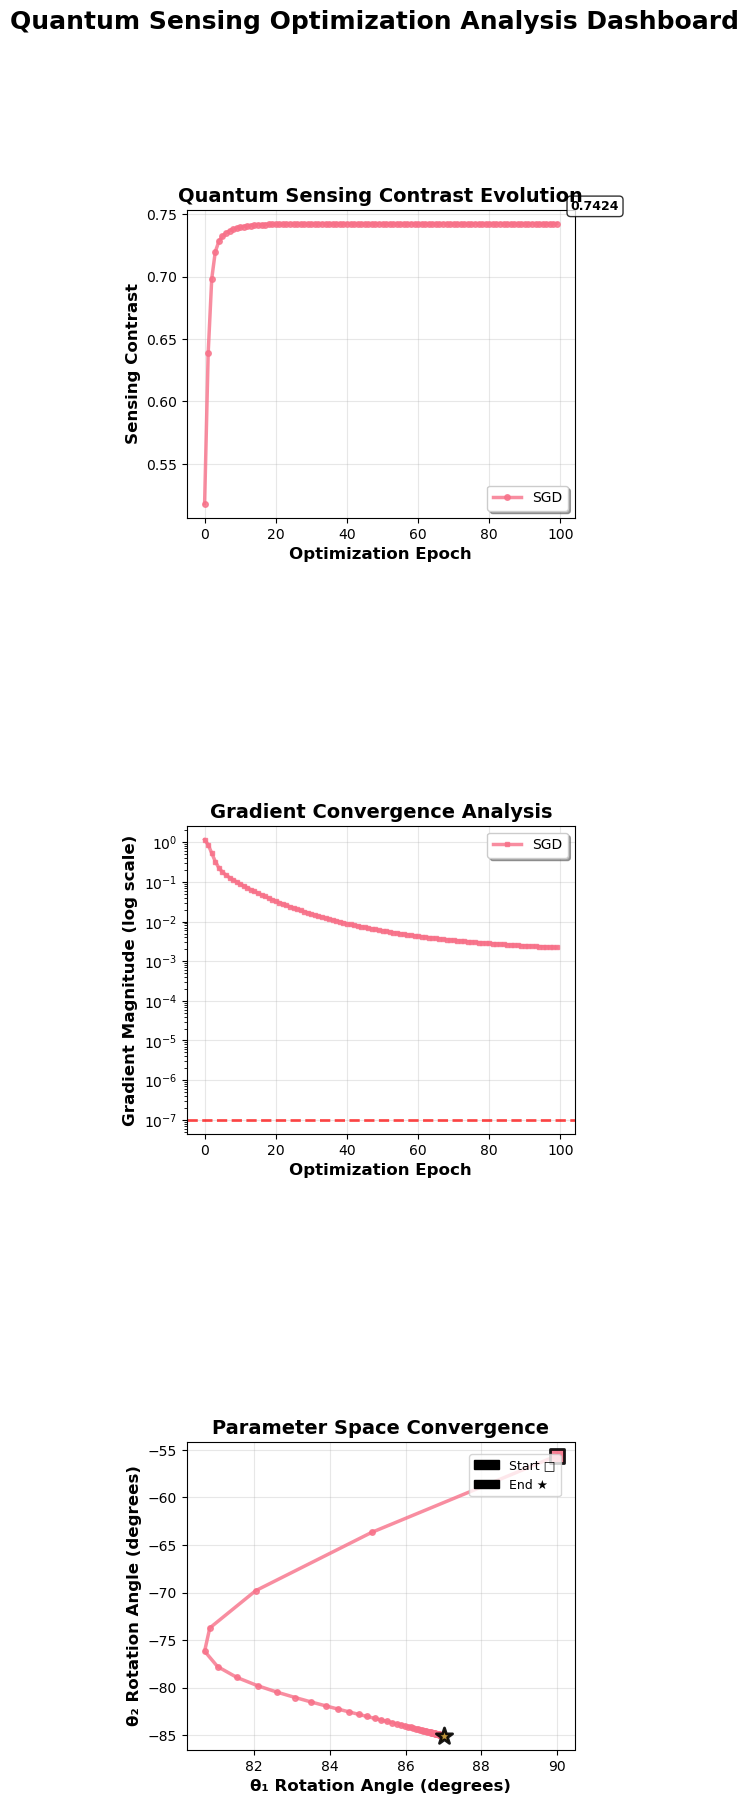

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.patches import FancyBboxPatch
import matplotlib.patches as mpatches

# Set up plotting style for publication quality
plt.style.use('default')
sns.set_palette("husl")

# Create comprehensive figure with subplots for optimization analysis
fig = plt.figure(figsize=(5, 20))

# ==================== SENSING CONTRAST EVOLUTION ====================
ax1 = plt.subplot(3, 1, 1)
for method, result in optimization_results.items():
    history = result['history']
    # For manual optimization, use contrast from loss
    epochs = range(len(history['loss']))
    contrast_values = -np.array(history['loss'])
    
    plt.plot(epochs, contrast_values, 
             linewidth=2.5, marker='o', markersize=4, 
             label=f'{method.upper()}', alpha=0.8)

plt.xlabel('Optimization Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Sensing Contrast', fontsize=12, fontweight='bold')
plt.title('Quantum Sensing Contrast Evolution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add final contrast values as text annotations
for i, (method, result) in enumerate(optimization_results.items()):
    final_contrast = result['contrast']
    plt.annotate(f'{final_contrast:.4f}', 
                xy=(len(result['history']['loss'])-1, final_contrast),
                xytext=(10, 10), textcoords='offset points',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8),
                fontsize=9, fontweight='bold')

# ==================== GRADIENT MAGNITUDE EVOLUTION ====================
ax2 = plt.subplot(3, 1, 2)
for method, result in optimization_results.items():
    history = result['history']
    epochs = range(len(history['gradients']))
    
    # Calculate gradient magnitude for each epoch
    grad_magnitudes = []
    for grad_pair in history['gradients']:
        if isinstance(grad_pair, list) and len(grad_pair) == 2:
            mag = np.sqrt(grad_pair[0]**2 + grad_pair[1]**2)
        else:
            mag = abs(grad_pair) if not isinstance(grad_pair, list) else 0
        grad_magnitudes.append(mag)
    
    plt.semilogy(epochs, grad_magnitudes, 
                linewidth=2.5, marker='s', markersize=3,
                label=f'{method.upper()}', alpha=0.8)

plt.xlabel('Optimization Epoch', fontsize=12, fontweight='bold')
plt.ylabel('Gradient Magnitude (log scale)', fontsize=12, fontweight='bold')
plt.title('Gradient Convergence Analysis', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add convergence threshold line
plt.axhline(y=1e-7, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Tolerance (1e-7)')

# ==================== PARAMETER SPACE CONVERGENCE (2D) ====================
ax3 = plt.subplot(3, 1, 3)
plt.subplots_adjust(hspace=1)

# Create parameter space trajectory plot
for method, result in optimization_results.items():
    history = result['history']
    theta0_traj = np.array(history['theta_values'])[:,0] + np.array(history['theta_values'])[:,1]
    theta1_traj = np.array(history['theta_values'])[:,0] - np.array(history['theta_values'])[:,1]
    
    # Plot optimization trajectory
    plt.plot(np.array(theta0_traj) * 180/np.pi, np.array(theta1_traj) * 180/np.pi, 
             linewidth=2.5, marker='o', markersize=4, alpha=0.8,
             label=f'{method.upper()}')
    
    # Mark starting point
    plt.scatter(theta0_traj[0] * 180/np.pi, theta1_traj[0] * 180/np.pi, 
               s=100, marker='s', edgecolors='black', linewidth=2, 
               alpha=0.9, zorder=5)
    
    # Mark ending point
    plt.scatter(theta0_traj[-1] * 180/np.pi, theta1_traj[-1] * 180/np.pi, 
               s=150, marker='*', edgecolors='black', linewidth=2, 
               alpha=0.9, zorder=5)

plt.xlabel('θ₁ Rotation Angle (degrees)', fontsize=12, fontweight='bold')
plt.ylabel('θ₂ Rotation Angle (degrees)', fontsize=12, fontweight='bold')
plt.title('Parameter Space Convergence', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10, frameon=True, fancybox=True, shadow=True)

# Add legend for markers
start_patch = mpatches.Patch(color='black', label='Start □')
end_patch = mpatches.Patch(color='black', label='End ★')
plt.legend(handles=[start_patch, end_patch], loc='upper right', 
          bbox_to_anchor=(0.98, 0.98), fontsize=9)

# Add overall title
fig.suptitle('Quantum Sensing Optimization Analysis Dashboard', 
            fontsize=18, fontweight='bold')

plt.show()

## Algorithms Optimization Benchmark (optional)

This section implements and compares multiple optimization strategies for quantum sensing parameter tuning.

In [24]:
# ==================== INITIAL STATE AND PARAMETERS ====================
# Initial state preparation: |0,1,0⟩ in composite space
with qt.CoreOptions(default_dtype="jax"):
    psi0 = qt.tensor(qt.basis(nlev, 1), qt.basis(nlev, 0), qt.basis(2, 0))
    rho0 = psi0 * psi0.dag()

print("QUANTUM SENSING OPTIMIZATION")
print("="*70)
print(f"Initial state: |0,1,0⟩ (vacuum input, 1 photon resonator, qubit ground)")
print(f"Measurement times: {tmeas}")

theta_init = [np.pi/6, -np.pi/3]  # Initial angles
print(f"\nInitial rotation angles: θ={theta_init[0]:.3f} rad ({theta_init[0]*180/np.pi:.1f}°)")
print(f"                        Δθ={theta_init[1]:.3f} rad ({theta_init[1]*180/np.pi:.1f}°)")

# Store all optimization results for comprehensive comparison
optimization_results = {}

# ==================== MANUAL GRADIENT DESCENT ====================
print("\n" + "="*70)
print("MANUAL GRADIENT DESCENT OPTIMIZATION")
print("="*70)

Theta_manual, history_manual = optimize_manual(
    args, rho0, tmeas, 
    theta_init=theta_init.copy(), 
    learning_rate=0.01, 
    max_iterations=160, 
    tolerance=1e-7,
    random=False
)

# Calculate final performance metrics
prob_with_manual = simulation(args, solver_interaction, rho0, Theta_manual, tmeas, random=False)
prob_without_manual = simulation(args, solver_no_interaction, rho0, Theta_manual, tmeas, random=False)
contrast_manual = prob_with_manual - prob_without_manual

optimization_results['manual'] = {
    'theta0': Theta_manual[0], 'theta1': Theta_manual[1], 
    'history': history_manual, 'contrast': contrast_manual,
    'prob_with': prob_with_manual, 'prob_without': prob_without_manual
}

print(f"\nMANUAL OPTIMIZATION RESULTS:")
print(f"Optimal angles: θ={Theta_manual[0]:.6f} rad ({Theta_manual[0]*180/np.pi:.2f}°)")
print(f"               Δθ={Theta_manual[1]:.6f} rad ({Theta_manual[1]*180/np.pi:.2f}°)")
print(f"Sensing contrast: {contrast_manual:.6f}")
print(f"Detection prob (with photon): {prob_with_manual:.6f}")
print(f"Detection prob (no photon): {prob_without_manual:.6f}")

# ==================== OPTAX OPTIMIZERS COMPARISON ====================
optimizers_to_test = ['adam', 'adamw', 'rmsprop', 'sgd']
learning_rates = {'adam': 0.1, 'adamw': 0.08, 'rmsprop': 0.15, 'sgd': 0.3}

print("\n" + "="*70)
print("OPTAX OPTIMIZERS BENCHMARK")
print("="*70)

for opt_name in optimizers_to_test:
    print(f"\n--- {opt_name.upper()} OPTIMIZATION ---")
    
    lr = learning_rates.get(opt_name, 0.1)
    params_optax, history_optax = optimize_optax(
        args, rho0, tmeas,
        theta_init=theta_init.copy(),
        optimizer_name=opt_name,
        learning_rate=lr,
        max_iterations=100,
        tolerance=1e-7,
        use_lr_schedule=(opt_name in ['adam', 'adamw']),  # Use scheduling for adaptive optimizers
        random=False
    )
    
    # Calculate performance metrics
    prob_with_optax = simulation(args, solver_interaction, rho0, params_optax, tmeas, random=False)
    prob_without_optax = simulation(args, solver_no_interaction, rho0, params_optax, tmeas, random=False)
    contrast_optax = prob_with_optax - prob_without_optax
    
    optimization_results[opt_name] = {
        'theta0': params_optax[0], 'theta1': params_optax[1],
        'history': history_optax, 'contrast': contrast_optax,
        'prob_with': prob_with_optax, 'prob_without': prob_without_optax
    }
    
    print(f"\n{opt_name.upper()} RESULTS:")
    print(f"Optimal angles: θ={params_optax[0]:.6f} rad ({params_optax[0]*180/np.pi:.2f}°)")
    print(f"               Δθ={params_optax[1]:.6f} rad ({params_optax[1]*180/np.pi:.2f}°)")
    print(f"Sensing contrast: {contrast_optax:.6f}")
    print(f"Iterations: {len(history_optax['loss'])}")

# ==================== COMPREHENSIVE COMPARISON SUMMARY ====================
print("\n" + "="*70)
print("OPTIMIZATION BENCHMARK SUMMARY")
print("="*70)

# Find best performing optimizer
best_method = max(optimization_results.keys(), 
                 key=lambda k: optimization_results[k]['contrast'])
best_contrast = optimization_results[best_method]['contrast']

print(f"BEST PERFORMING OPTIMIZER: {best_method.upper()}")
print(f"Maximum sensing contrast: {best_contrast:.6f}")
print("\nFull Rankings:")
print("-" * 50)
print("Method\t\tContrast\tIterations\tθ₁ (deg)\tθ₂ (deg)")
print("-" * 50)

# Sort results by contrast for ranking
sorted_results = sorted(optimization_results.items(), 
                       key=lambda x: x[1]['contrast'], reverse=True)

for i, (method, result) in enumerate(sorted_results):
    iterations = len(result['history']['contrast'])
    theta1_deg = result['theta0'] * 180 / np.pi
    theta2_deg = result['theta1'] * 180 / np.pi
    
    print(f"{method:<12}\t{result['contrast']:.6f}\t{iterations:3d}\t\t{theta1_deg:6.2f}\t\t{theta2_deg:6.2f}")

# Statistical analysis
contrasts = [result['contrast'] for result in optimization_results.values()]
print(f"\nStatistical Analysis:")
print(f"  Mean contrast: {np.mean(contrasts):.6f}")
print(f"  Std deviation: {np.std(contrasts):.6f}")
print(f"  Range: {np.max(contrasts) - np.min(contrasts):.6f}")

print("\nComprehensive optimization benchmark complete!")

QUANTUM SENSING OPTIMIZATION
Initial state: |0,1,0⟩ (vacuum input, 1 photon resonator, qubit ground)
Measurement times: [-265.25823849 -132.62911924    0.          132.62911924  265.25823849]

Initial rotation angles: θ=0.524 rad (30.0°)
                        Δθ=-1.047 rad (-60.0°)

MANUAL GRADIENT DESCENT OPTIMIZATION
Starting manual gradient descent optimization
Initial angles: θ=0.524 rad, Δθ=-1.047 rad
Iter	Theta		Delta Theta	Grad0		Grad1		Loss
--------------------------------------------------------------------------------
  0	0.523599	-1.047198	-0.858782	-0.262030	0.175477
  1	0.515011	-1.073401	-0.897522	-0.255952	0.189808
  2	0.506036	-1.098996	-0.935398	-0.249384	0.204504
  3	0.496682	-1.123934	-0.972198	-0.242354	0.219561
  4	0.486960	-1.148169	-1.007706	-0.234892	0.234971
  5	0.476883	-1.171659	-1.041694	-0.227029	0.250726
  6	0.466466	-1.194362	-1.073932	-0.218799	0.266810
  7	0.455726	-1.216241	-1.104186	-0.210239	0.283203
  8	0.444685	-1.237265	-1.132221	-0.201390	0.299

KeyboardInterrupt: 